# 先行研究の再現Part3：ガウス過程回帰による推定
## データ準備

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
!pip show pymc
!pip show pytensor
!pip show arviz

2.4.2
3.0.1
3.10.8
Name: pymc
Version: 5.28.2
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic Machine Learning with PyTensor
Home-page: http://github.com/pymc-devs/pymc
Author: 
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: arviz, cachetools, cloudpickle, numpy, pandas, pytensor, rich, scipy, threadpoolctl, typing-extensions
Required-by: 
Name: pytensor
Version: 2.38.2
Summary: Optimizing compiler for evaluating mathematical expressions on CPUs and GPUs.
Home-page: https://github.com/pymc-devs/pytensor
Author: 
Author-email: pymc-devs <pymc.devs@gmail.com>
License-Expression: BSD-3-Clause
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: cons, etuples, filelock, logical-unification, miniKanren, numba, numpy, scipy, setuptools
Required-by: pymc
Name: arviz
Version: 0.23.4
Summary: Exploratory analysis of Bayesian models
Home-page: http://github.com/arviz-devs/a

In [6]:
# read csv
from pathlib import Path
csv_path = Path("../data/raw/M.csv")
df = pd.read_csv(csv_path)

# set index to Year
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df = df.set_index("Year")
print("===to DatetimeIndex===")
print(type(df.index))
print("====DatetimeIndex====")

# normalization
df["SG_norm"] = df["D_SG"] / df["SG"] * 3000
df["IG_norm"] = df["D_IG"] / df["IG"] * 3000
df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

csv_path_para = Path("init_para/init.csv")
csv_path_y = Path("init_y/y.csv")

init_para = pd.read_csv(csv_path_para)
init_y = pd.read_csv(csv_path_y)
init_y["Year"] = pd.to_datetime(init_y["Year"])
init_y = init_y.set_index("Year")

init_para_fit = init_para[
    ["group", "lambda0_init", "alpha0_init", "theta_hat", "gamma_hat"]
]

===to DatetimeIndex===
<class 'pandas.DatetimeIndex'>
====DatetimeIndex====


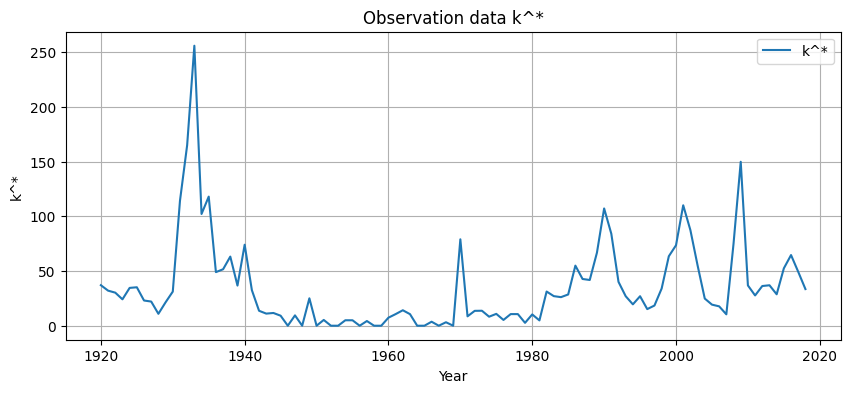

In [34]:
plt.figure(figsize=(10, 4))

plt.plot(df["ALL_norm"].index, df["ALL_norm"], label="k^*")
plt.title("Observation data k^*")
plt.xlabel("Year")
plt.ylabel("k^*")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
init_y["ALL"].head()

Year
1920-01-01    0.544809
1921-01-01    0.389823
1922-01-01    0.326757
1923-01-01    0.086248
1924-01-01    0.470981
Name: ALL, dtype: float64

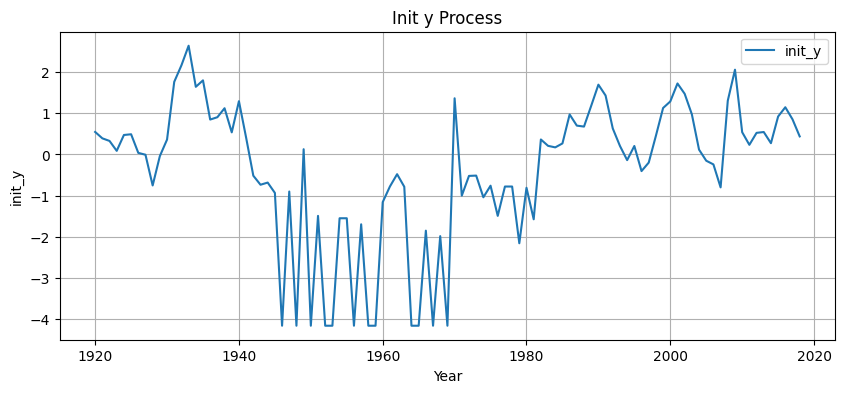

In [32]:
plt.figure(figsize=(10, 4))

plt.plot(init_y["ALL"].index, init_y["ALL"], label="init_y")
plt.title("Init y Process")
plt.xlabel("Year")
plt.ylabel("init_y")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
init_para_fit[init_para_fit["group"] == "ALL"]

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat
0,ALL,22.745634,0.918828,0.840086,0.508958


In [92]:
row_all = init_para_fit[init_para_fit["group"] == "ALL"].iloc[0]
lambda0_init = float(row_all["lambda0_init"])
alpha_init  = float(row_all["alpha0_init"])
theta_init    = float(row_all["theta_hat"])
gamma_init    = float(row_all["gamma_hat"])

ここまでで$k^* , y_t^{init} , \lambda_0^{init} , \alpha^{init} , \theta^{init} , \gamma^{init}$

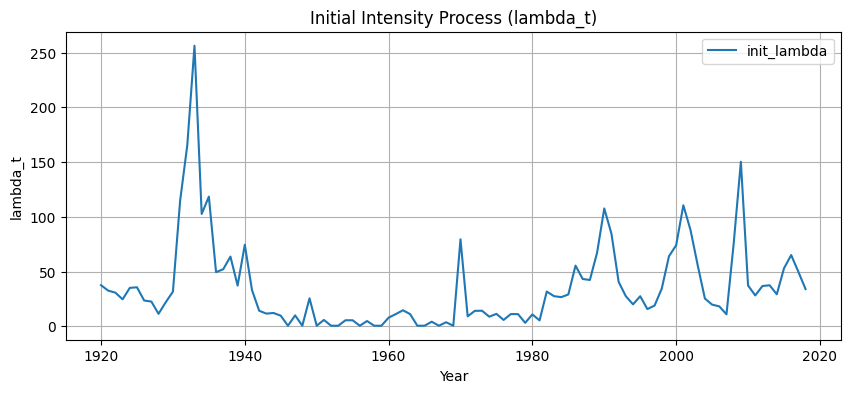

In [93]:
init_lambda = lambda0_init * np.exp(alpha_init * init_y["ALL"])
init_lambda = pd.DataFrame({
    "init_lambda": init_lambda
}, index=init_y["ALL"].index)

plt.figure(figsize=(10, 4))

plt.plot(init_lambda.index, init_lambda["init_lambda"], label="init_lambda")
plt.title("Initial Intensity Process (lambda_t)")
plt.xlabel("Year")
plt.ylabel("lambda_t")

plt.legend()
plt.grid(True)

plt.show()

## モデル
### 指数減衰
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)\ , y_t \sim \mathcal{GP}(0, k(t, t')) 
$$

$$
k(t,t+h) = \exp{\left(-\frac{h}{l}\right)}\ ,\ \theta = \exp{(-l^{-1})}
$$


$$
\ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})\ ,\ \alpha \sim \mathcal{N^+}(\mu_{\alpha} , \sigma^2_{\alpha})\ ,\ \theta \sim \text{Beta}(a,b)
$$

分散メモ

$\eta_0$

初期値をかなり信用するなら 0.3〜0.5、少し広めなら 0.7 です。



収束性重視事前分布
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)\ , y_t \sim \mathcal{GP}(0, k(t, t')) 
$$
$$
k(t,t+h) = \exp{\left(-\frac{h}{l}\right)}\ ,\ \theta = \exp{(-l^{-1})}\ , \ 
l = -\frac{1}{\log{\theta}}
$$
$$
\ \eta_0 \sim \mathcal{N}(\eta^{init}_0 , 0.5^2)\ ,\ \alpha \sim \mathcal{N^+}(\alpha^{init} , 0.3^2)
$$

$$
\log{l} \sim \mathcal{N} (\log{(-1/\log{\theta^{init}})} , 0.5^2)
$$

In [48]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

# =========================================
# 1. データ準備
# =========================================

# 観測データ
k_data = df["ALL_norm"].to_numpy(dtype=float)

# Poisson の観測値として整数化
k_obs = np.rint(k_data).astype("int64")
T = len(k_obs)

# 時間軸（年次データなので 0,1,2,...,T-1 で十分）
t = np.arange(T, dtype=float)[:, None]

# 初期値
row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]

lambda0_init = float(row_all["lambda0_init"])
eta0_init = float(np.log(lambda0_init))

alpha_init = float(row_all["alpha0_init"])
theta_init = float(row_all["theta_hat"])

# theta -> ell 変換
ell_init = float(-1.0 / np.log(theta_init))
log_ell_init = float(np.log(ell_init))

# 潜在変数の初期値
y_init = init_y["ALL"].to_numpy(dtype=float)

print("T             =", T)
print("eta0_init     =", eta0_init)
print("alpha_init    =", alpha_init)
print("theta_init    =", theta_init)
print("ell_init      =", ell_init)
print("log_ell_init  =", log_ell_init)

T             = 99
eta0_init     = 3.1243732056434244
alpha_init    = 0.9188280249138177
theta_init    = 0.8400863742899627
ell_init      = 5.738862280655782
log_ell_init  = 1.7472609817405005


In [57]:
with pm.Model() as gp_poisson_model:
    eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
    alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=0.3, lower=0.0)
    log_ell = pm.Normal("log_ell", mu=log_ell_init, sigma=0.5)

    ell = pm.Deterministic("ell", pt.exp(log_ell))

    cov = pm.gp.cov.Exponential(input_dim=1, ls=ell)
    gp = pm.gp.Latent(cov_func=cov)
    y = gp.prior("y", X=t, jitter=1e-6)

    mu = pm.Deterministic("mu", pt.exp(eta0 + alpha * y))
    x = pm.Poisson("x", mu=mu, observed=k_obs)

In [58]:
with gp_poisson_model:
    map_est = pm.find_MAP()

map_est.keys()

C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

dict_keys(['eta0', 'alpha_interval__', 'log_ell', 'y_rotated_', 'alpha', 'ell', 'y', 'mu'])

In [59]:
print("MAP eta0    =", map_est["eta0"])
print("MAP alpha   =", map_est["alpha"])
print("MAP log_ell =", map_est["log_ell"])
print("MAP ell     =", np.exp(map_est["log_ell"]))

MAP eta0    = 2.9515401303775297
MAP alpha   = 2.2603181814528863
MAP log_ell = -0.03160325960389727
MAP ell     = 0.9688909039971737


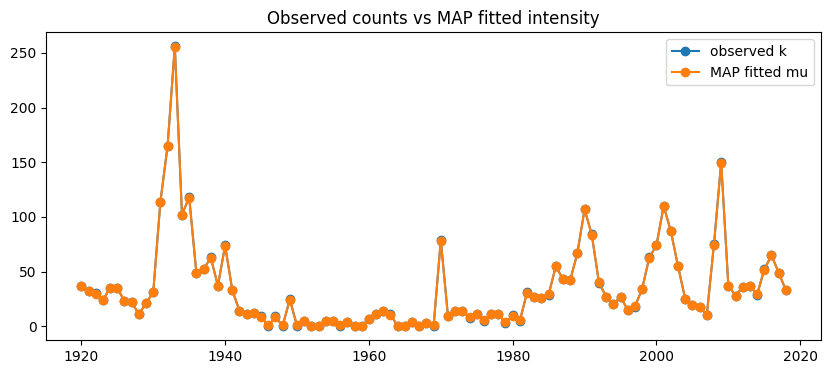

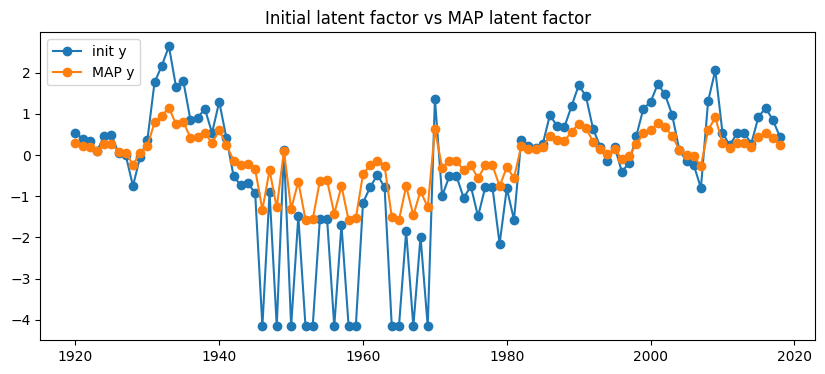

In [60]:
y_map = map_est["y"]
mu_map = np.exp(map_est["eta0"] + map_est["alpha"] * y_map)

plt.figure(figsize=(10, 4))
plt.plot(df.index, k_obs, marker="o", label="observed k")
plt.plot(df.index, mu_map, marker="o", label="MAP fitted mu")
plt.legend()
plt.title("Observed counts vs MAP fitted intensity")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df.index, y_init, marker="o", label="init y")
plt.plot(df.index, y_map, marker="o", label="MAP y")
plt.legend()
plt.title("Initial latent factor vs MAP latent factor")
plt.show()

In [61]:
with gp_poisson_model:
    trace_gp = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=2,
        target_accept=0.95,
        init="jitter+adapt_diag",
        random_seed=42,
        initvals={
            "eta0": eta0_init,
            "alpha": alpha_init,
            "log_ell": log_ell_init,
        },
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y_rotated_]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 189 seconds.
C:\Users\h20s1\workspace\.venv\Lib\site-packages\pymc\model\fgraph.py:160: UserWarning: Detected variables likely created by GP objects. Further use of these old GP objects should be avoided as it may reintroduce variables from the old model. See issue: https://github.com/pymc-devs/pymc/issues/6883
  warnings.warn(
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [62]:
az.summary(trace_gp, var_names=["eta0", "alpha", "log_ell", "ell"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
eta0,3.021,0.324,2.468,3.683,0.013,0.008,584.0,828.0,1.01
alpha,1.359,0.158,1.066,1.651,0.006,0.003,672.0,1036.0,1.01
log_ell,1.056,0.269,0.582,1.567,0.012,0.006,537.0,771.0,1.01
ell,2.982,0.829,1.715,4.654,0.034,0.023,537.0,771.0,1.01


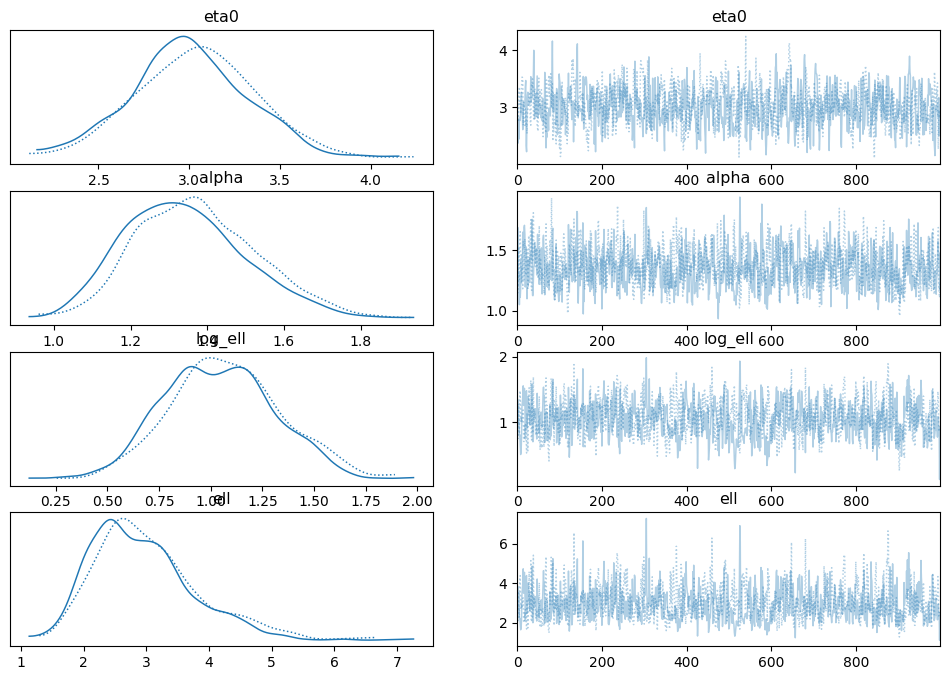

In [63]:
az.plot_trace(trace_gp, var_names=["eta0", "alpha", "log_ell", "ell"])
plt.show()

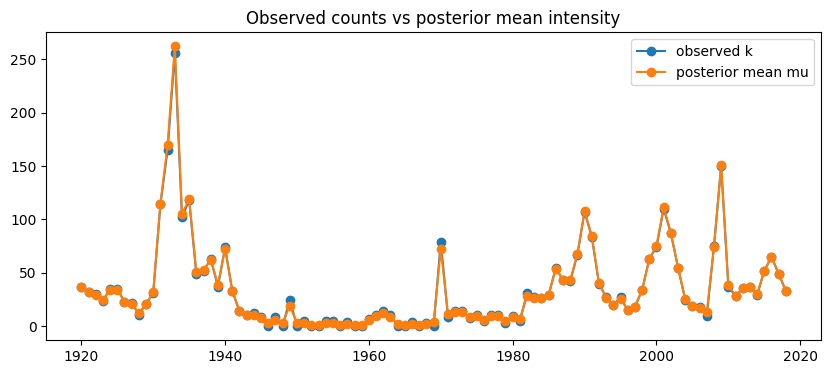

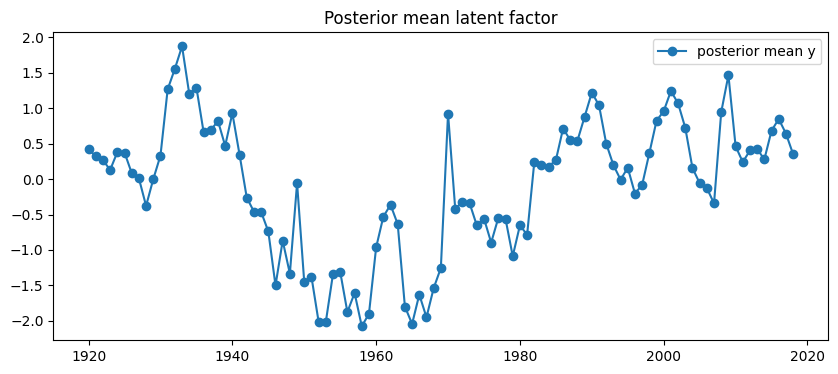

In [64]:
eta0_post = trace_gp.posterior["eta0"].mean(dim=("chain", "draw")).item()
alpha_post = trace_gp.posterior["alpha"].mean(dim=("chain", "draw")).item()
y_post = trace_gp.posterior["y"].mean(dim=("chain", "draw")).values

mu_post = np.exp(eta0_post + alpha_post * y_post)

plt.figure(figsize=(10, 4))
plt.plot(df.index, k_obs, marker="o", label="observed k")
plt.plot(df.index, mu_post, marker="o", label="posterior mean mu")
plt.legend()
plt.title("Observed counts vs posterior mean intensity")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df.index, y_post, marker="o", label="posterior mean y")
plt.legend()
plt.title("Posterior mean latent factor")
plt.show()

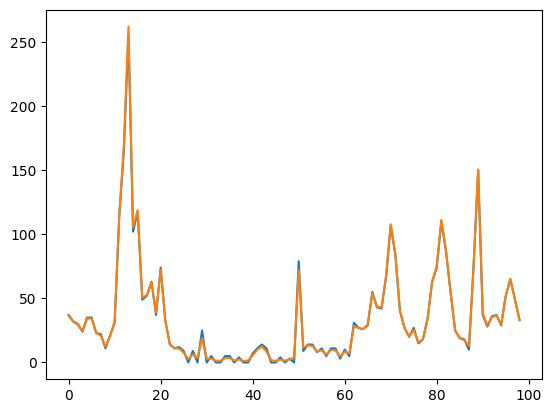

In [65]:
plt.plot(k_obs)
plt.plot(mu_post)

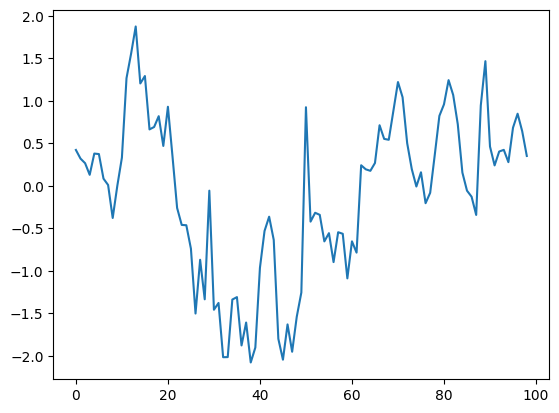

In [66]:
plt.plot(y_post)

In [67]:
theta_samples = np.exp(-1 / trace_gp.posterior["ell"].values)
theta_samples.mean()

np.float64(0.7005838917753351)

In [ ]:
az.waic(trace_gp)

In [68]:
az.loo(trace_gp)

C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -352.60     8.26
p_loo       78.56        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       28   28.3%
   (0.70, 1]   (bad)        59   59.6%
   (1, Inf)   (very bad)   12   12.1%

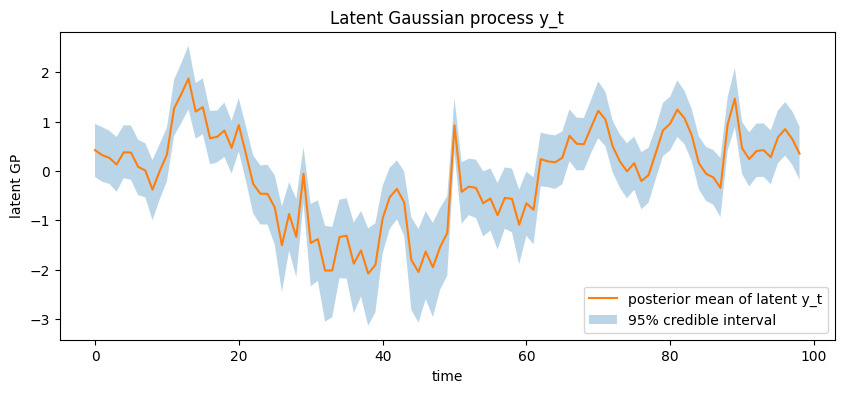

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# posterior の y: (chain, draw, time)
y_samples = trace_gp.posterior["y"].stack(sample=("chain", "draw")).values  # shape: (T, S) ではなく注意
# xarray -> numpy の軸順が環境で違うことがあるので安全に転置
if y_samples.shape[0] != T:
    y_samples = y_samples.T

y_mean = y_samples.mean(axis=1)
y_lower = np.quantile(y_samples, 0.025, axis=1)
y_upper = np.quantile(y_samples, 0.975, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(T), y_mean, color="tab:orange", label="posterior mean of latent y_t")
plt.fill_between(np.arange(T), y_lower, y_upper, alpha=0.3, label="95% credible interval")
plt.xlabel("time")
plt.ylabel("latent GP")
plt.title("Latent Gaussian process y_t")
plt.legend()
plt.show()

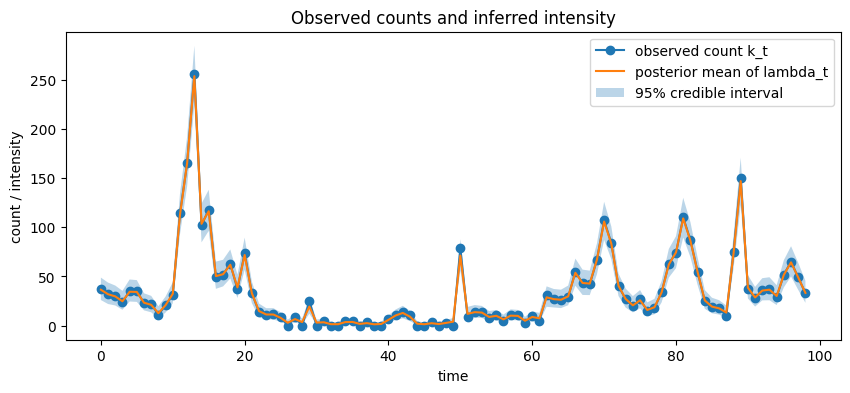

In [70]:
eta0_samples = trace_gp.posterior["eta0"].stack(sample=("chain", "draw")).values
alpha_samples = trace_gp.posterior["alpha"].stack(sample=("chain", "draw")).values
y_samples = trace_gp.posterior["y"].stack(sample=("chain", "draw")).values
if y_samples.shape[0] != T:
    y_samples = y_samples.T

# 各 posterior sample ごとの lambda_t
lambda_samples = np.exp(eta0_samples[None, :] + alpha_samples[None, :] * y_samples)

lam_mean = lambda_samples.mean(axis=1)
lam_lower = np.quantile(lambda_samples, 0.025, axis=1)
lam_upper = np.quantile(lambda_samples, 0.975, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(T), k_obs, "o-", label="observed count k_t")
plt.plot(np.arange(T), lam_mean, "-", label="posterior mean of lambda_t")
plt.fill_between(np.arange(T), lam_lower, lam_upper, alpha=0.3, label="95% credible interval")
plt.xlabel("time")
plt.ylabel("count / intensity")
plt.title("Observed counts and inferred intensity")
plt.legend()
plt.show()

In [73]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy.special import gammaln, logsumexp

def build_gp_poisson_model(k_train, eta0_init, alpha_init, log_ell_init):
    T_train = len(k_train)
    t_train = np.arange(T_train, dtype=float)[:, None]

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=0.3, lower=0.0)
        log_ell = pm.Normal("log_ell", mu=log_ell_init, sigma=0.5)
        ell = pm.Deterministic("ell", pt.exp(log_ell))

        cov = pm.gp.cov.Exponential(input_dim=1, ls=ell)
        gp = pm.gp.Latent(cov_func=cov)
        y = gp.prior("y", X=t_train, jitter=1e-6)

        mu = pm.Deterministic("mu", pt.exp(eta0 + alpha * y))
        pm.Poisson("x", mu=mu, observed=k_train)

    return model


def one_step_lfo_logscore_gp(trace, x_next):
    eta0_s = trace.posterior["eta0"].stack(sample=("chain", "draw")).values
    alpha_s = trace.posterior["alpha"].stack(sample=("chain", "draw")).values
    y_s = trace.posterior["y"].stack(sample=("chain", "draw")).values

    # y_s shape を (T, S) にそろえる
    if y_s.shape[0] != len(trace.posterior["y"].coords["y_dim_0"]):
        y_s = y_s.T

    # 簡易版:
    # 1期先の潜在因子 y_{t+1} を、最後の y_t で近似
    # （厳密なGP条件付き予測ではなく、軽量近似）
    y_last = y_s[-1, :]

    lam_next = np.exp(eta0_s + alpha_s * y_last)

    # Poisson log pmf
    logp = x_next * np.log(lam_next) - lam_next - gammaln(x_next + 1)

    # log mean exp
    return logsumexp(logp) - np.log(len(logp))


def compute_lfo_gp(
    k_obs,
    eta0_init,
    alpha_init,
    log_ell_init,
    t0=60,
    draws=300,
    tune=300,
    chains=2,
    cores=2,
    target_accept=0.95,
    random_seed=42,
):
    T = len(k_obs)
    lfo_scores = []

    for t in range(t0, T - 1):
        print(f"LFO fold: train=0..{t}, test={t+1}")

        k_train = k_obs[: t + 1]
        x_next = int(k_obs[t + 1])

        model = build_gp_poisson_model(
            k_train=k_train,
            eta0_init=eta0_init,
            alpha_init=alpha_init,
            log_ell_init=log_ell_init,
        )

        with model:
            trace = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                cores=cores,
                target_accept=target_accept,
                init="jitter+adapt_diag",
                random_seed=random_seed,
                progressbar=False,
            )

        logscore = one_step_lfo_logscore_gp(trace, x_next)
        lfo_scores.append(logscore)

    lfo_total = np.sum(lfo_scores)
    return lfo_total, lfo_scores

In [74]:
k_obs = np.rint(df["ALL_norm"].to_numpy(dtype=float)).astype("int64")

row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]
lambda0_init = float(row_all["lambda0_init"])
eta0_init = float(np.log(lambda0_init))
alpha_init = float(row_all["alpha0_init"])
theta_init = float(row_all["theta_hat"])

ell_init = -1.0 / np.log(theta_init)
log_ell_init = np.log(ell_init)

lfo_total, lfo_scores = compute_lfo_gp(
    k_obs=k_obs,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    log_ell_init=log_ell_init,
    t0=60,
    draws=300,
    tune=300,
    chains=2,
    cores=2,
    target_accept=0.95,
    random_seed=42,
)

print("LFO total =", lfo_total)
print("n_folds   =", len(lfo_scores))

LFO fold: train=0..60, test=61


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y_rotated_]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 42 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LFO fold: train=0..61, test=62


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y_rotated_]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 45 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LFO fold: train=0..62, test=63


...

LFO fold: train=0..96, test=97


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y_rotated_]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 74 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LFO fold: train=0..97, test=98


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y_rotated_]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 71 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LFO total = -294.0751131640251
n_folds   = 38


### べき減衰
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)\ , y_t \sim \mathcal{GP}(0, k(t, t')) 
$$

$$
k(t,t+h) = \frac{1}{(1 + h)^{\gamma}}
$$

$$
\ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})\ ,\ \alpha \sim \mathcal{N^+}(\mu_{\alpha} , \sigma^2_{\alpha})\ ,\ \gamma \sim \text{Gamma}(a,b)
$$


収束性重視事前分布
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)\ , y_t \sim \mathcal{GP}(0, k(t, t')) 
$$

$$
k(t,t+h) = \frac{1}{(1 + h)^{\gamma}}
$$
$$
\ \eta_0 \sim \mathcal{N}(\eta^{init}_0 , 0.5^2)\ ,\ \alpha \sim \mathcal{N^+}(\alpha^{init} , 0.3^2)
$$

$$
\log{\gamma} \sim \mathcal{N} (\log{\gamma^{init}} , 0.4^2)
$$

In [77]:
init_para_fit

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat
0,ALL,22.745634,0.918828,0.840086,0.508958
1,SG,58.528809,0.855271,0.812694,0.566471
2,IG,2.090132,1.202780,0.745700,0.685032


In [78]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp

# =========================================
# 0. データ準備
# =========================================
k_obs = np.rint(df["ALL_norm"].to_numpy(dtype=float)).astype("int64")
T = len(k_obs)
t_idx = np.arange(T, dtype=float)

row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]

lambda0_init = float(row_all["lambda0_init"])
eta0_init = float(np.log(lambda0_init))
alpha_init = float(row_all["alpha0_init"])
theta_init = float(row_all["theta_hat"])
gamma_init = float(row_all["gamma_hat"])

ell_init = float(-1.0 / np.log(theta_init))
log_ell_init = float(np.log(ell_init))
log_gamma_init = float(np.log(gamma_init))

y_init = init_y["ALL"].to_numpy(dtype=float)

print("T =", T)
print("eta0_init =", eta0_init)
print("alpha_init =", alpha_init)
print("theta_init =", theta_init)
print("ell_init =", ell_init)
print("gamma_init =", gamma_init)

T = 99
eta0_init = 3.1243732056434244
alpha_init = 0.9188280249138177
theta_init = 0.8400863742899627
ell_init = 5.738862280655782
gamma_init = 0.5089581516717917


In [79]:
# =========================================
# 1. カーネル行列
# =========================================
def pairwise_dist_1d(x):
    x = np.asarray(x, dtype=float)
    return np.abs(x[:, None] - x[None, :])

def kernel_exp_np(x, ell):
    D = pairwise_dist_1d(x)
    return np.exp(-D / ell)

def kernel_pow_np(x, gamma):
    D = pairwise_dist_1d(x)
    return 1.0 / ((1.0 + D) ** gamma)

In [80]:
def build_exp_gp_model(k_train, t_train, eta0_init, alpha_init, log_ell_init, jitter=1e-6):
    T_train = len(k_train)
    D = pairwise_dist_1d(t_train)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=0.3, lower=0.0)

        log_ell = pm.Normal("log_ell", mu=log_ell_init, sigma=0.5)
        ell = pm.Deterministic("ell", pt.exp(log_ell))

        K = pt.exp(-pt.as_tensor_variable(D) / ell)
        K = K + jitter * pt.eye(T_train)

        y = pm.MvNormal("y", mu=pt.zeros(T_train), cov=K, shape=T_train)

        mu = pm.Deterministic("mu", pt.exp(eta0 + alpha * y))
        pm.Poisson("x", mu=mu, observed=k_train)

    return model

def build_pow_gp_model(k_train, t_train, eta0_init, alpha_init, log_gamma_init, jitter=1e-6):
    T_train = len(k_train)
    D = pairwise_dist_1d(t_train)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.TruncatedNormal("alpha", mu=alpha_init, sigma=0.3, lower=0.0)

        log_gamma = pm.Normal("log_gamma", mu=log_gamma_init, sigma=0.4)
        gamma = pm.Deterministic("gamma", pt.exp(log_gamma))

        K = (1.0 + pt.as_tensor_variable(D)) ** (-gamma)
        K = K + jitter * pt.eye(T_train)

        y = pm.MvNormal("y", mu=pt.zeros(T_train), cov=K, shape=T_train)

        mu = pm.Deterministic("mu", pt.exp(eta0 + alpha * y))
        pm.Poisson("x", mu=mu, observed=k_train)

    return model

In [81]:
# =========================================
# 2. フィット関数
# =========================================
def fit_model(model, initvals=None, draws=1000, tune=1000, chains=2, cores=2,
              target_accept=0.95, random_seed=42):
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            init="jitter+adapt_diag",
            random_seed=random_seed,
            initvals=initvals,
            idata_kwargs={"log_likelihood": True},
        )
    return idata

In [82]:
# =========================================
# 3. 全期間推定
# =========================================
exp_model = build_exp_gp_model(
    k_train=k_obs,
    t_train=t_idx,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    log_ell_init=log_ell_init,
)

pow_model = build_pow_gp_model(
    k_train=k_obs,
    t_train=t_idx,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    log_gamma_init=log_gamma_init,
)

trace_exp = fit_model(
    exp_model,
    initvals={
        "eta0": eta0_init,
        "alpha": alpha_init,
        "log_ell": log_ell_init,
    },
    draws=1000,
    tune=1000,
)

trace_pow = fit_model(
    pow_model,
    initvals={
        "eta0": eta0_init,
        "alpha": alpha_init,
        "log_gamma": log_gamma_init,
    },
    draws=1000,
    tune=1000,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 94 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 143 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [83]:
# =========================================
# 4. WAIC / LOO
# =========================================
waic_exp = az.waic(trace_exp)
loo_exp = az.loo(trace_exp)

waic_pow = az.waic(trace_pow)
loo_pow = az.loo(trace_pow)

print("=== Exponential GP ===")
print(waic_exp)
print(loo_exp)

print("\n=== Power-law GP ===")
print(waic_pow)
print(loo_pow)

C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See

=== Exponential GP ===
Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -331.56     7.00
p_waic       58.02        -

There has been a warning during the calculation. Please check the results.
Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -353.92     8.36
p_loo       80.38        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       27   27.3%
   (0.70, 1]   (bad)        63   63.6%
   (1, Inf)   (very bad)    9    9.1%


=== Power-law GP ===
Computed from 2000 posterior samples and 99 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -323.68     6.17
p_waic       53.91        -

There has been a warning during the calculation. Please check the results.
Computed from 2000 posterior samples and 99 

C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [84]:
compare_waic = az.compare(
    {"exp_gp": trace_exp, "pow_gp": trace_pow},
    ic="waic"
)

compare_loo = az.compare(
    {"exp_gp": trace_exp, "pow_gp": trace_pow},
    ic="loo"
)

print("=== WAIC comparison ===")
print(compare_waic)

print("\n=== LOO comparison ===")
print(compare_loo)

C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robus

=== WAIC comparison ===
        rank   elpd_waic     p_waic  elpd_diff        weight        se  \
pow_gp     0 -323.676689  53.905262   0.000000  1.000000e+00  6.172072   
exp_gp     1 -331.563402  58.023997   7.886713  1.487699e-14  7.001166   

             dse  warning scale  
pow_gp  0.000000     True   log  
exp_gp  2.499629     True   log  

=== LOO comparison ===
        rank    elpd_loo      p_loo  elpd_diff        weight        se  \
pow_gp     0 -343.935912  74.164485   0.000000  1.000000e+00  6.792379   
exp_gp     1 -353.919906  80.380501   9.983994  1.293410e-14  8.361004   

             dse  warning scale  
pow_gp  0.000000     True   log  
exp_gp  3.673398     True   log  


C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


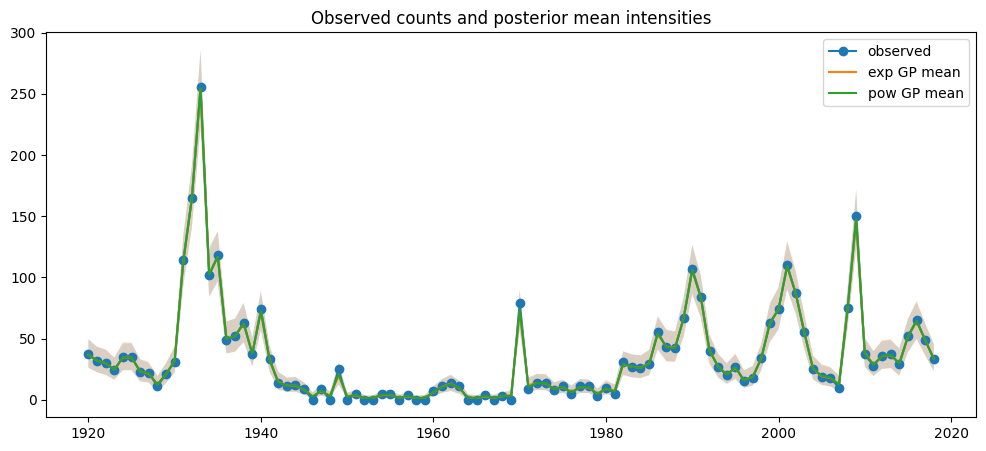

In [85]:
# =========================================
# 5. フィット結果の可視化
# =========================================
def posterior_mu_mean(idata):
    eta0_s = idata.posterior["eta0"].stack(sample=("chain", "draw")).values
    alpha_s = idata.posterior["alpha"].stack(sample=("chain", "draw")).values
    y_s = idata.posterior["y"].stack(sample=("chain", "draw")).values

    if y_s.shape[0] != T:
        y_s = y_s.T

    mu_s = np.exp(eta0_s[None, :] + alpha_s[None, :] * y_s)
    mu_mean = mu_s.mean(axis=1)
    mu_low = np.quantile(mu_s, 0.025, axis=1)
    mu_high = np.quantile(mu_s, 0.975, axis=1)
    return mu_mean, mu_low, mu_high

mu_exp, mu_exp_low, mu_exp_high = posterior_mu_mean(trace_exp)
mu_pow, mu_pow_low, mu_pow_high = posterior_mu_mean(trace_pow)

plt.figure(figsize=(12, 5))
plt.plot(df.index, k_obs, "o-", label="observed")
plt.plot(df.index, mu_exp, label="exp GP mean")
plt.fill_between(df.index, mu_exp_low, mu_exp_high, alpha=0.2)
plt.plot(df.index, mu_pow, label="pow GP mean")
plt.fill_between(df.index, mu_pow_low, mu_pow_high, alpha=0.2)
plt.legend()
plt.title("Observed counts and posterior mean intensities")
plt.show()

In [87]:
# =========================================
# 6. GP 条件付き 1期先予測
# =========================================
def gp_conditional_next_sample(y_train, x_train, x_next, kernel_func, kernel_param,
                               n_mc=30, jitter=1e-6, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    K = kernel_func(x_train, kernel_param) + jitter * np.eye(len(x_train))
    k_star = kernel_cross(x_train, x_next, kernel_func, kernel_param)   # shape (T,)
    k_ss = kernel_self(x_next, kernel_func, kernel_param) + jitter

    K_inv = np.linalg.inv(K)
    mean_star = k_star @ K_inv @ y_train
    var_star = k_ss - k_star @ K_inv @ k_star
    var_star = max(var_star, 1e-10)

    return rng.normal(loc=mean_star, scale=np.sqrt(var_star), size=n_mc)

def kernel_cross(x_train, x_next, kernel_func, kernel_param):
    x_train = np.asarray(x_train, dtype=float)
    x_next = float(x_next)

    if kernel_func is kernel_exp_np:
        return np.exp(-np.abs(x_train - x_next) / kernel_param)
    elif kernel_func is kernel_pow_np:
        return 1.0 / ((1.0 + np.abs(x_train - x_next)) ** kernel_param)
    else:
        raise ValueError("Unknown kernel function")

def kernel_self(x_next, kernel_func, kernel_param):
    return 1.0

In [88]:
def one_step_logpred_gp(idata, model_type, x_train, x_next, y_name="y", n_mc=30, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    eta0_s = idata.posterior["eta0"].stack(sample=("chain", "draw")).values
    alpha_s = idata.posterior["alpha"].stack(sample=("chain", "draw")).values
    y_s = idata.posterior["y"].stack(sample=("chain", "draw")).values

    if y_s.shape[0] != len(x_train):
        y_s = y_s.T

    if model_type == "exp":
        param_s = idata.posterior["ell"].stack(sample=("chain", "draw")).values
        kernel_func = kernel_exp_np
    elif model_type == "pow":
        param_s = idata.posterior["gamma"].stack(sample=("chain", "draw")).values
        kernel_func = kernel_pow_np
    else:
        raise ValueError("model_type must be 'exp' or 'pow'")

    S = eta0_s.shape[0]
    logp_all = []

    for s in range(S):
        y_next_draws = gp_conditional_next_sample(
            y_train=y_s[:, s],
            x_train=x_train,
            x_next=x_next,
            kernel_func=kernel_func,
            kernel_param=param_s[s],
            n_mc=n_mc,
            rng=rng
        )

        lam_draws = np.exp(eta0_s[s] + alpha_s[s] * y_next_draws)
        logp_draws = x_next * np.log(lam_draws) - lam_draws - gammaln(x_next + 1)

        # posterior sample s の中で latent future を積分
        logp_s = logsumexp(logp_draws) - np.log(n_mc)
        logp_all.append(logp_s)

    # posterior でも積分
    return logsumexp(logp_all) - np.log(len(logp_all))

In [89]:
# =========================================
# 7. LFO
# =========================================
def compute_lfo_gp(model_type, k_obs, t0,
                   eta0_init, alpha_init,
                   log_ell_init=None, log_gamma_init=None,
                   draws=300, tune=300, chains=2, cores=2,
                   target_accept=0.95, random_seed=42):
    T = len(k_obs)
    scores = []

    for t in range(t0, T - 1):
        print(f"[{model_type}] fold train=0..{t}, test={t+1}")

        k_train = k_obs[:t+1]
        x_next = int(k_obs[t+1])
        t_train = np.arange(len(k_train), dtype=float)
        t_next = float(len(k_train))

        if model_type == "exp":
            model = build_exp_gp_model(
                k_train=k_train,
                t_train=t_train,
                eta0_init=eta0_init,
                alpha_init=alpha_init,
                log_ell_init=log_ell_init,
            )
            initvals = {
                "eta0": eta0_init,
                "alpha": alpha_init,
                "log_ell": log_ell_init,
            }

        elif model_type == "pow":
            model = build_pow_gp_model(
                k_train=k_train,
                t_train=t_train,
                eta0_init=eta0_init,
                alpha_init=alpha_init,
                log_gamma_init=log_gamma_init,
            )
            initvals = {
                "eta0": eta0_init,
                "alpha": alpha_init,
                "log_gamma": log_gamma_init,
            }

        else:
            raise ValueError("model_type must be 'exp' or 'pow'")

        idata = fit_model(
            model,
            initvals=initvals,
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            random_seed=random_seed,
        )

        fold_score = one_step_logpred_gp(
            idata=idata,
            model_type=model_type,
            x_train=t_train,
            x_next=t_next,
            n_mc=30,
        )
        scores.append(fold_score)

    return np.sum(scores), scores

In [90]:
# =========================================
# 8. LFO 実行
# =========================================
lfo_exp_total, lfo_exp_scores = compute_lfo_gp(
    model_type="exp",
    k_obs=k_obs,
    t0=60,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    log_ell_init=log_ell_init,
    draws=300,
    tune=300,
    chains=2,
    cores=2,
    target_accept=0.95,
    random_seed=42,
)

lfo_pow_total, lfo_pow_scores = compute_lfo_gp(
    model_type="pow",
    k_obs=k_obs,
    t0=60,
    eta0_init=eta0_init,
    alpha_init=alpha_init,
    log_gamma_init=log_gamma_init,
    draws=300,
    tune=300,
    chains=2,
    cores=2,
    target_accept=0.95,
    random_seed=42,
)

print("LFO exp total =", lfo_exp_total)
print("LFO pow total =", lfo_pow_total)

[exp] fold train=0..60, test=61


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_ell, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[exp] fold train=0..61, test=62


...

[pow] fold train=0..97, test=98


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, log_gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 54 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LFO exp total = -224.84844054246017
LFO pow total = -224.00446944688468


In [91]:
# =========================================
# 9. 比較表
# =========================================
summary_df = az.compare(
    {"exp_gp": trace_exp, "pow_gp": trace_pow},
    ic="waic"
).copy()

summary_simple = {
    "exp_gp": {
        "WAIC_elpd": float(waic_exp.elpd_waic),
        "WAIC_p": float(waic_exp.p_waic),
        "LOO_elpd": float(loo_exp.elpd_loo),
        "LOO_p": float(loo_exp.p_loo),
        "LFO_total": float(lfo_exp_total),
    },
    "pow_gp": {
        "WAIC_elpd": float(waic_pow.elpd_waic),
        "WAIC_p": float(waic_pow.p_waic),
        "LOO_elpd": float(loo_pow.elpd_loo),
        "LOO_p": float(loo_pow.p_loo),
        "LFO_total": float(lfo_pow_total),
    },
}

import pandas as pd
summary_simple = pd.DataFrame(summary_simple).T
print(summary_simple)

         WAIC_elpd     WAIC_p    LOO_elpd      LOO_p   LFO_total
exp_gp -331.563402  58.023997 -353.919906  80.380501 -224.848441
pow_gp -323.676689  53.905262 -343.935912  74.164485 -224.004469


C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
